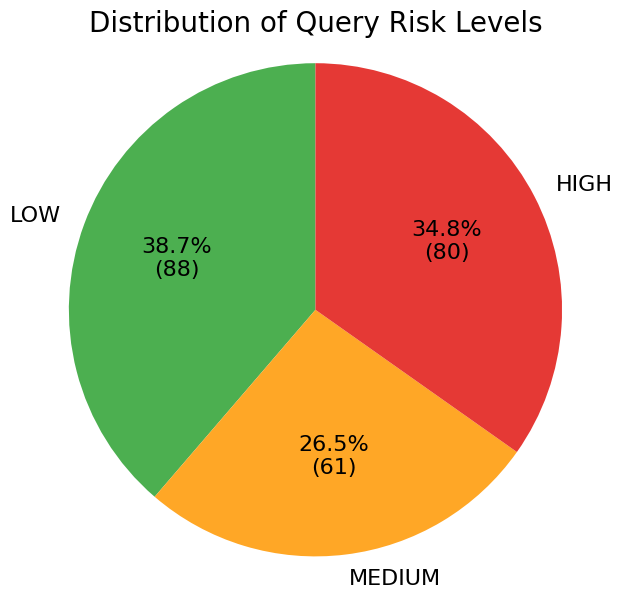


Risk Level Counts
Risk_Level
LOW       89
MEDIUM    61
HIGH      80
Name: count, dtype: int64

Risk Level Percentages
Risk_Level
LOW       38.70
MEDIUM    26.52
HIGH      34.78
Name: count, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load results
df = pd.read_csv("Results/QRS_results.csv")

# risk level counts
risk_counts = df["Risk_Level"].value_counts()

# consistent order
order = ["LOW", "MEDIUM", "HIGH"]
risk_counts = risk_counts.reindex(order)

# colors
colors = ["#4CAF50", "#FFA726", "#E53935"]  # green, orange, red

plt.figure(figsize=(7,7))

wedges, texts, autotexts = plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100.*risk_counts.sum())})",
    startangle=90,
    colors=colors,
    textprops={'fontsize':16}
)

# title
plt.title("Distribution of Query Risk Levels", fontsize=20)

plt.axis('equal')

# SAVE FIGURE
plt.savefig("Results/Figures/QRS_risk_level_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("Results/Figures/QRS_risk_level_distribution.pdf", bbox_inches="tight")

plt.show()

# -----------------------------
# PRINT STATISTICS
# -----------------------------

print("\nRisk Level Counts")
print(risk_counts)

print("\nRisk Level Percentages")
print((risk_counts / len(df) * 100).round(2))

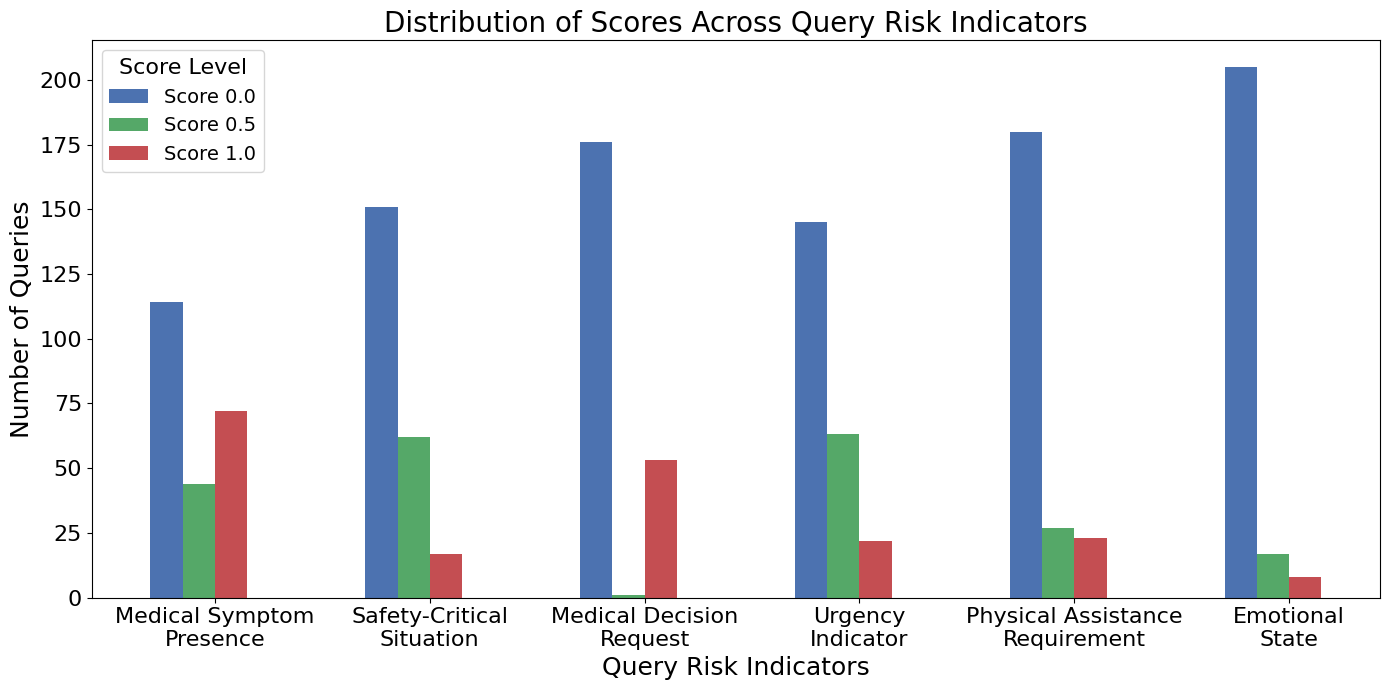

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load results
df = pd.read_csv("Results/QRS_results.csv")

categories = ["MS","SC","MD","UE","PA","ES"]

category_labels = [
    "Medical Symptom\nPresence",
    "Safety-Critical\nSituation",
    "Medical Decision\nRequest",
    "Urgency\nIndicator",
    "Physical Assistance\nRequirement",
    "Emotional\nState"
]

score_levels = sorted(df[categories].stack().unique())

counts = {score: [] for score in score_levels}

for score in score_levels:
    for cat in categories:
        counts[score].append((df[cat] == score).sum())

x = np.arange(len(categories))
width = 0.15

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

plt.figure(figsize=(14,7))

for i,score in enumerate(score_levels):
    plt.bar(
        x + i*width,
        counts[score],
        width=width,
        label=f"Score {score}",
        color=colors[i]
    )

plt.xticks(x + width*(len(score_levels)/2), category_labels, fontsize=16)
plt.yticks(fontsize=16)

plt.xlabel("Query Risk Indicators", fontsize=18)
plt.ylabel("Number of Queries", fontsize=18)

plt.title("Distribution of Scores Across Query Risk Indicators", fontsize=20)

plt.legend(title="Score Level", fontsize=14, title_fontsize=16)

plt.tight_layout()

# SAVE FIGURE
plt.savefig("Results/Figures/QRS_indicator_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("Results/Figures/QRS_indicator_distribution.pdf", bbox_inches="tight")

plt.show()

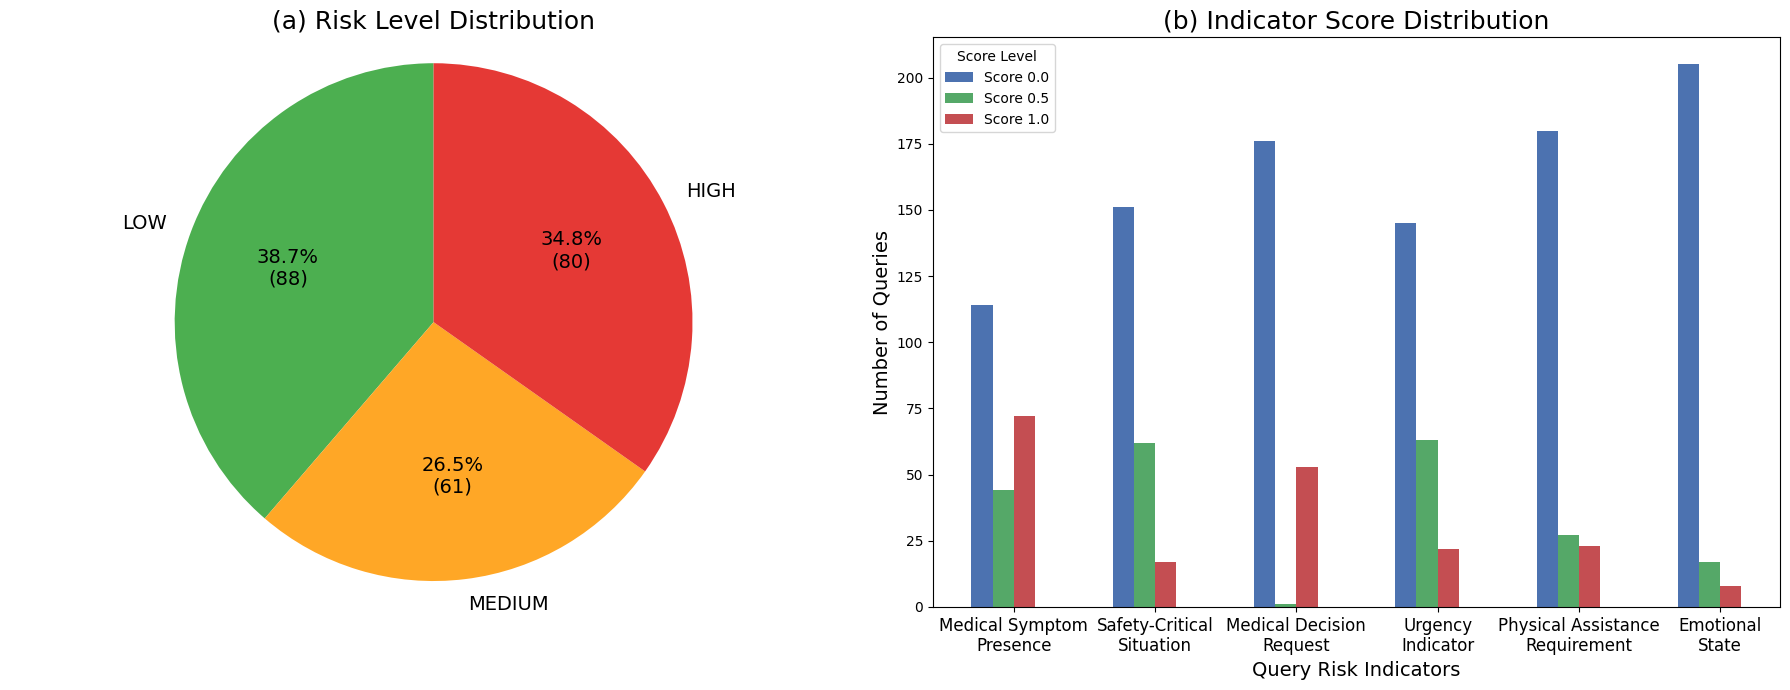

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load results
df = pd.read_csv("Results/QRS_results.csv")

# =============================
# CREATE FIGURE WITH 2 SUBPLOTS
# =============================
fig, axes = plt.subplots(1, 2, figsize=(18,7))

# ======================================================
# (a) PIE CHART – Risk Level Distribution
# ======================================================

risk_counts = df["Risk_Level"].value_counts()
order = ["LOW", "MEDIUM", "HIGH"]
risk_counts = risk_counts.reindex(order)

colors_pie = ["#4CAF50", "#FFA726", "#E53935"]

wedges, texts, autotexts = axes[0].pie(
    risk_counts,
    labels=risk_counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100.*risk_counts.sum())})",
    startangle=90,
    colors=colors_pie,
    textprops={'fontsize':14}
)

axes[0].set_title("(a) Risk Level Distribution", fontsize=18)
axes[0].axis('equal')


# ======================================================
# (b) BAR CHART – Indicator Distribution
# ======================================================

categories = ["MS","SC","MD","UE","PA","ES"]

category_labels = [
    "Medical Symptom\nPresence",
    "Safety-Critical\nSituation",
    "Medical Decision\nRequest",
    "Urgency\nIndicator",
    "Physical Assistance\nRequirement",
    "Emotional\nState"
]

score_levels = sorted(df[categories].stack().unique())

counts = {score: [] for score in score_levels}

for score in score_levels:
    for cat in categories:
        counts[score].append((df[cat] == score).sum())

x = np.arange(len(categories))
width = 0.15

colors_bar = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

for i, score in enumerate(score_levels):
    axes[1].bar(
        x + i*width,
        counts[score],
        width=width,
        label=f"Score {score}",
        color=colors_bar[i]
    )

axes[1].set_xticks(x + width*(len(score_levels)/2))
axes[1].set_xticklabels(category_labels, fontsize=12)

axes[1].set_xlabel("Query Risk Indicators", fontsize=14)
axes[1].set_ylabel("Number of Queries", fontsize=14)

axes[1].set_title("(b) Indicator Score Distribution", fontsize=18)

axes[1].legend(title="Score Level", fontsize=10)

# =============================
# FINAL LAYOUT
# =============================
plt.tight_layout()

# SAVE
plt.savefig("Results/Figures/QRS_combined_figure.png", dpi=300, bbox_inches="tight")
plt.savefig("Results/Figures/QRS_combined_figure.pdf", bbox_inches="tight")

plt.show()